In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [4]:
b10= bd.iloc[175]

In [5]:
b10['datetime']

'2020-11-18,07:52:51.134129+00:00'

In [6]:
lat= literal_eval(b10['lat_stereo_g16'])
long= literal_eval(b10['lat_stereo_g16'])
alt= literal_eval(b10['alt_stereo_g16'])
energy = literal_eval(b10['energyJoules_stereo_g16'])

In [7]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [8]:
print (len(lat), len(long), len(alt), len(energy))

235 235 235 235


In [9]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

146


In [10]:
totalmass= 0
totalh= 0 
for i in range (146): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [11]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.0006403386061149296 0.00029882468285363377 0.0029882468285363385


In [12]:
totalh

75723.7793387077

In [13]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

0.0016088200000012876
-6.670000004760368e-06
0.0007822600000082502
0.0011905499999897984
-0.0006391199999882247
0.00036742999999717085
0.00015825999999208307
-3.1089999993128004e-05
0.0018027600000039001
0.0004603899999864325
0.00024995000001126755
0.0014832699999942633
-0.0041940299999936315
-0.0028452700000087816
-0.0030347399999897107
-0.00568624000000284
0.0030454899999909912
0.0032477499999998827
0.003435559999999782
0.006481210000004012
-0.0014359999999982165
-0.0016467199999965487
-0.0018601499999988391
-0.003312280000002943
-0.0001939800000059222
5.85000000086211e-05
0.0002411799999890718
-5.508999998937725e-05
-0.00043369000000836877
-0.0003301299999947105
-0.0007332499999961328
-0.00022167000000195003
9.509999998158492e-06
0.0004770799999960218
-0.8830164700000012
-0.5977554299999923
-0.3304817799999995
-0.3202416100000107
-1.0472862199999895
0.010982720000001223
0.04621883000000082
0.04217989999999361
0.15324078999999813
0.03169915000000856
0.04351944999999091
0.098456949999

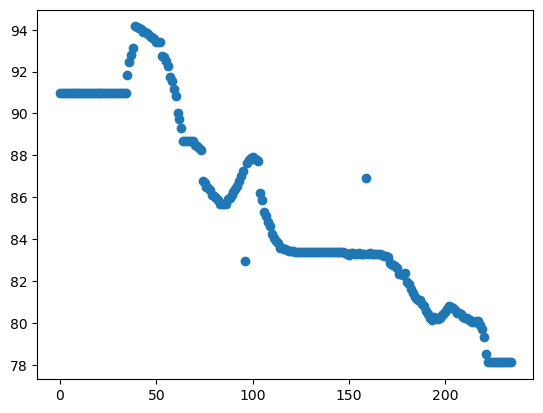

In [14]:
plt.scatter(range(len(alt)), alt)